In [2]:
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import torchvision.transforms as transforms

# Exercise 4 - Medical images as arrays, filters, and augmentations

Welcome to your **first image-processing lab**.  
Today, you will act like a **digital pathologist** for a few minutes.

We will use a microscopy image of cancer tissue to explore three ideas:

1. **An image is an array of numbers**
2. **A convolution filter can highlight or smooth structures**
3. **Data augmentation creates realistic image variations for training Neural Networks**


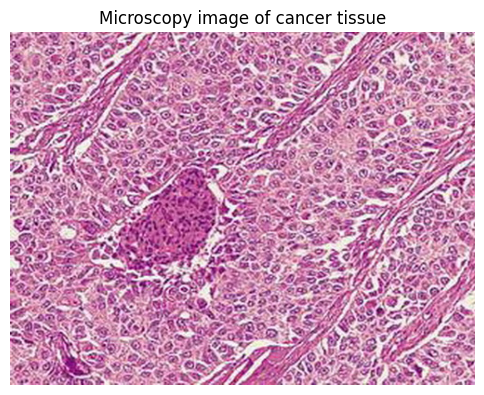

Shape of the image array: (380, 500, 3)
Example pixel (one tiny point in the image): [0.6039216  0.43529412 0.54509807]


In [3]:
# Download a microscopy image
!wget -q https://github.com/CS4MS/CS4MS_exercise/raw/main/images/Cancer.jpg -O Cancer.jpg

# Load image
image = mpimg.imread('Cancer.jpg').astype(np.float32)

# Normalize to values between 0 and 1 if needed
if image.max() > 1:
    image = image / 255.0

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title('Microscopy image of cancer tissue')
plt.axis('off')
plt.show()

print('Shape of the image array:', image.shape)
print('Example pixel (one tiny point in the image):', image[100, 100])

## 1) Images as arrays

A computer does **not** see "cells" or "tissue". It sees a large table of numbers. For a color image, the shape is usually:

**(height, width, channels)**

So if the shape is something like `(380, 500, 3)`, the last value `3` means:
- red channel
- green channel
- blue channel

Each pixel has one value for each of these three colors (3 channels).
By mixing different amounts of red, green, and blue, we can create almost any color.

Examples:

* `(255, 0, 0)` = pure red
* `(0, 255, 0)` = pure green
* `(0, 0, 255)` = pure blue
* `(255, 255, 0)` = yellow
* `(255, 255, 255)` = white
* `(0, 0, 0)` = black


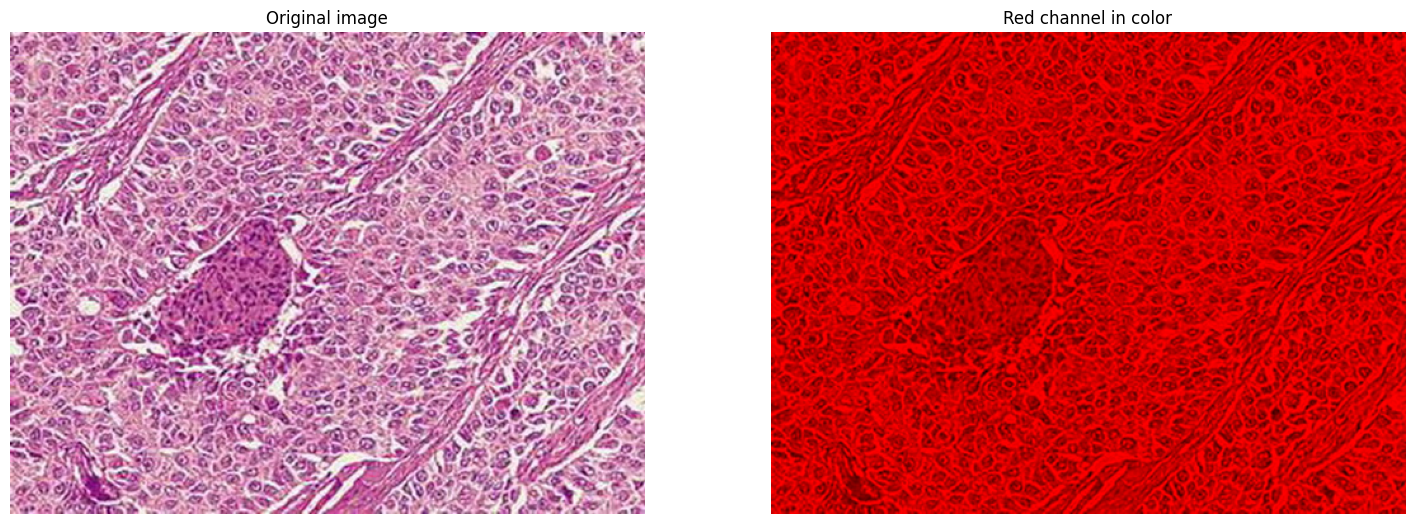

In [4]:
#### Exercise 1 ####
# Change channel_to_show to 0, 1, or 2 and run the cell again.
# What structures become more visible?

channel_to_show = 0

# Solutions:
# channel_to_show = 0  # red
# channel_to_show = 1  # green
# channel_to_show = 2  # blue

colored_channel = np.zeros_like(image)
colored_channel[:, :, channel_to_show] = image[:, :, channel_to_show]

channel_names = ['Red', 'Green', 'Blue']

plt.figure(figsize=(18, 10))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(colored_channel)
plt.title(f'{channel_names[channel_to_show]} channel in color')
plt.axis('off')

plt.show()

## 2) Convolution: a tiny filter moves across the image

A **convolution filter** is a very small matrix, for example `3 x 3`, that slides over the image.

At each position, the computer:
1. looks at a small neighborhood of pixels,
2. multiplies them with the filter values,
3. adds the results.

This lets us create different effects:
- **blur** -> smooths the image
- **edge** -> highlights boundaries
- **sharpen** -> makes details stronger

In medicine, edge-like filters can make boundaries more visible, for example around cells or tissue structures.


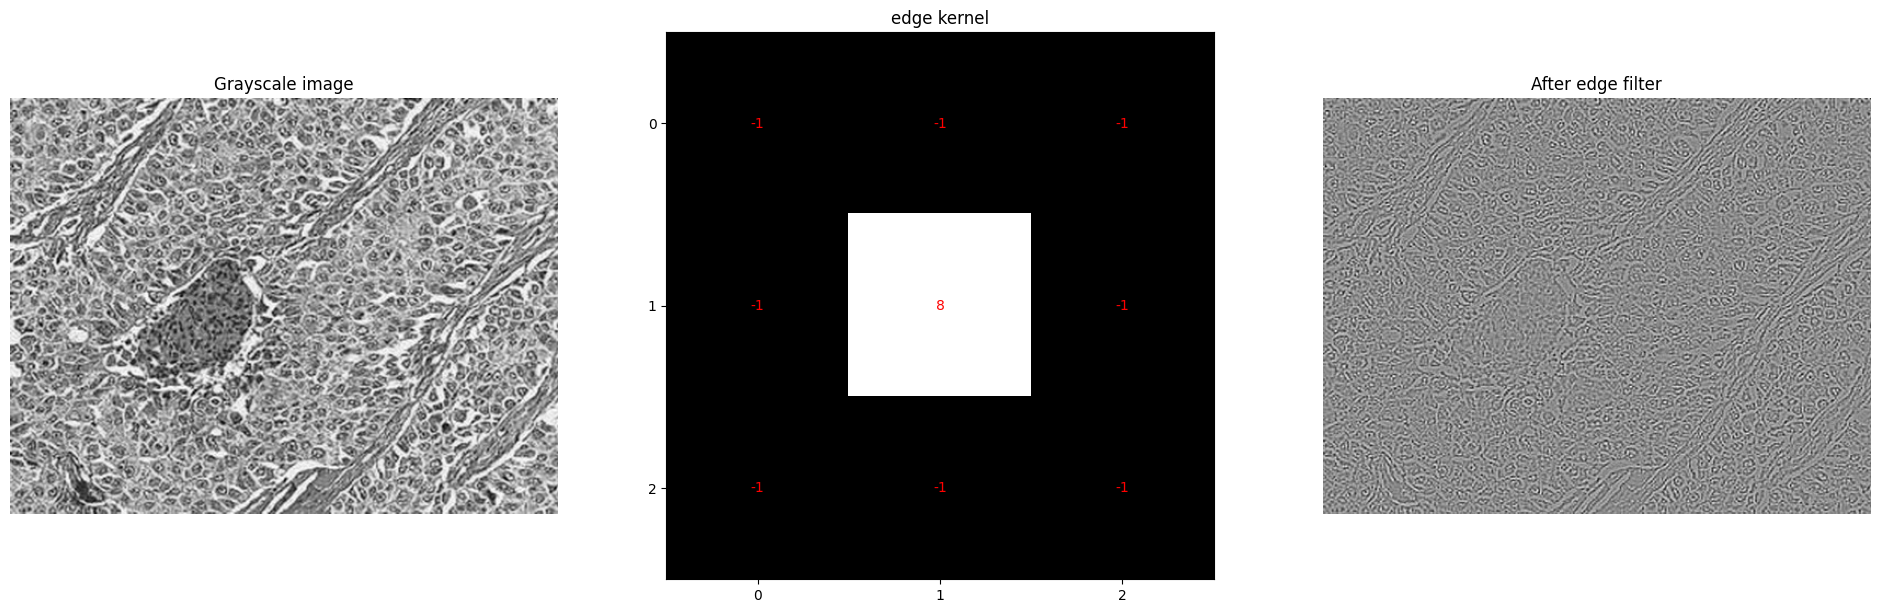

In [5]:
# Convert to grayscale (one number per pixel instead of 3)
gray = np.dot(image[..., :3], [0.299, 0.587, 0.114])

# Definition of filters
kernels = {
    'edge': np.array([[-1, -1, -1],
                      [-1,  8, -1],
                      [-1, -1, -1]]),
    'sharpen': np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]]),
    'blur': np.ones((3, 3)) / 9
}

#### Exercise 2 ####
# Try 'edge', 'sharpen', or 'blur' and observe differences in the resulting image
kernel_name = 'edge'

# Solutions:
# kernel_name = 'edge'
# kernel_name = 'sharpen'
# kernel_name = 'blur'

filtered = ndimage.convolve(gray, kernels[kernel_name], mode='reflect')

plt.figure(figsize=(24, 10))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Grayscale image')
plt.axis('off')

plt.subplot(1, 3, 2)
kernel = kernels[kernel_name]
plt.imshow(kernel, cmap='gray')
plt.title(f'{kernel_name} kernel')

for i in range(kernel.shape[0]):
    for j in range(kernel.shape[1]):
        plt.text(j, i, f'{kernel[i, j]:.2g}', ha='center', va='center', color='red')

plt.xticks(range(kernel.shape[1]))
plt.yticks(range(kernel.shape[0]))

plt.subplot(1, 3, 3)
plt.imshow(filtered, cmap='gray')
plt.title(f'After {kernel_name} filter')
plt.axis('off')

plt.show()

## 3) Data augmentation: making realistic image variations

**Data augmentation** means creating slightly modified versions of an image.

### Why do we use data augmentation for training neural networks?

Neural networks usually need many training images. In medicine, this is often difficult:

- datasets can be small

- labeling images is time consuming

- images can vary because of rotation, brightness, staining, zoom, or acquisition settings

Data augmentation helps by creating slightly changed versions of the same image during training --> makes the effect of having more data.

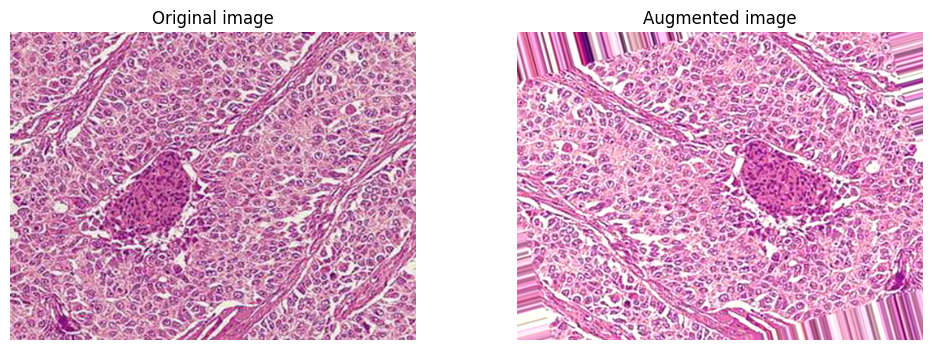

In [6]:
# Exercise 3:
# Change the values below and create a realistic new version of the image.

angle = 15
flip_left_right = True
brightness_factor = 1.15

# Solutions:
# angle = -10
# flip_left_right = False
# brightness_factor = 0.90
#
# angle = 20
# flip_left_right = True
# brightness_factor = 1.05

augmented = image.copy()

if flip_left_right:
    augmented = np.fliplr(augmented)

augmented = ndimage.rotate(augmented, angle, reshape=False, mode='nearest')
augmented = np.clip(augmented * brightness_factor, 0, 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Original image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(augmented)
plt.title('Augmented image')
plt.axis('off')

plt.show()

### Trasnforms

`torchvision.transforms` is a very useful library because it already contains many image transformations. So we do not need to program operations like rotation, brightness change, or flipping ourselves.

The goal of this exercise is to choose one transformation, apply it to the image, then change its parameter and observe the result.

Feel free to explore the documentation of this library and try as many transforms as you want :)
https://docs.pytorch.org/vision/0.8/transforms.html


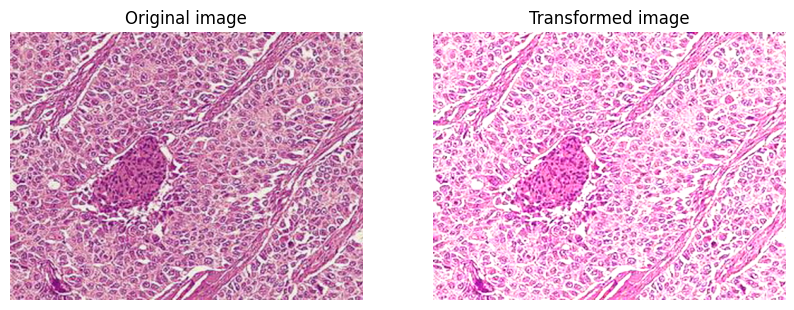

In [7]:
# Convert the NumPy image to a PIL image
img = Image.fromarray((image * 255).astype(np.uint8))

#### Exercise 4 ####
# 1. Try different transforms.
# 2. Run the cell.
# 3. Change the parameter and run it again.

transform = transforms.ColorJitter(brightness=0.8)

# HINTs: transforms to try:
# transform = transforms.ColorJitter(brightness=0.8)
# transform = transforms.RandomHorizontalFlip(p=1.0)
# transform = transforms.RandomRotation(degrees=10)
# Explore other transforms from the library documentation

# Apply the transform
augmented_img = transform(img)

# Show original and transformed image
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(augmented_img)
plt.title("Transformed image")
plt.axis("off")

plt.show()

# Questions:
# 1. Which transform looks most realistic for this medical image?
# 2. What happens when you increase the parameter?
# 3. Which transform could help a neural network learn better?

# Solutions:
# - A small rotation can be realistic because the orientation of an image may vary.
# - A small brightness change can be realistic because image acquisition may differ.
# - A horizontal flip can sometimes help, but in some medical tasks orientation may matter.
# - Very strong transformations may create unrealistic images.

## Recap

Try to answer these after running the notebook:

1. In `image.shape`, what does the last number `3` mean?
2. Which filter makes boundaries stand out most: **blur**, **edge**, or **sharpen**?
3. Why might rotation and brightness changes be realistic in medical imaging?

<!--
Solutions:
1. The 3 stands for the three color channels: red, green, and blue.
2. The edge filter highlights boundaries the most.
3. Because medical images can vary due to scanner settings, slide orientation, staining, illumination, or acquisition conditions.
-->
